# 06 — Cubes, the two Lazuli fields and the detector image

An IFS delivers a 3D **cube** (2 spatial × 1 spectral dimensions), not just a spectrum.
`slicersim` simulates it.

Lazuli is a **two-field** IFS:

| field | spaxel size | slices on the detector |
|---|---|---|
| `"narrow"` | 40 mas | 1–58 |
| `"wide"` | 80 mas | 59–116 |

The narrow field samples the PSF well (e.g. for low-redshift SNe, to separate them from their host);
the wide field collects more light per spaxel (e.g. for faint, high-redshift SNe). The slices of
both fields are dispersed side by side onto the **same** detector.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

In [2]:
snia = slicersim.LazuliSupernova(redshift=1.0)
snia.change_detector(nmd=(64, 8, 0), nramps=3)
snia.get_spectrograph_field()

('narrow', {'spatial_shape': [58, 58], 'spatial_scale': 0.04})

***
## 1. The cube of the current field

`get_cube(which="current")` returns the signal cube and its variance cube, in ADU, with shape
`(n_wavelength, n_slices, n_pixels_along_slice)`.

In [3]:
cube, varcube = snia.get_cube(which="current")
lbda = snia.simulation.spectrograph.lbda
print(cube.shape, lbda.shape)

(525, 58, 116) (525,)


The cube contains the target, the zodiacal background and the thermal signal (the dark
current is subtracted), while the variance cube includes all the variance sources. As for
spectra, the cube is noise-free; draw a noise realisation from the variance:

In [4]:
cube_noisy = np.random.normal(cube, np.sqrt(varcube))

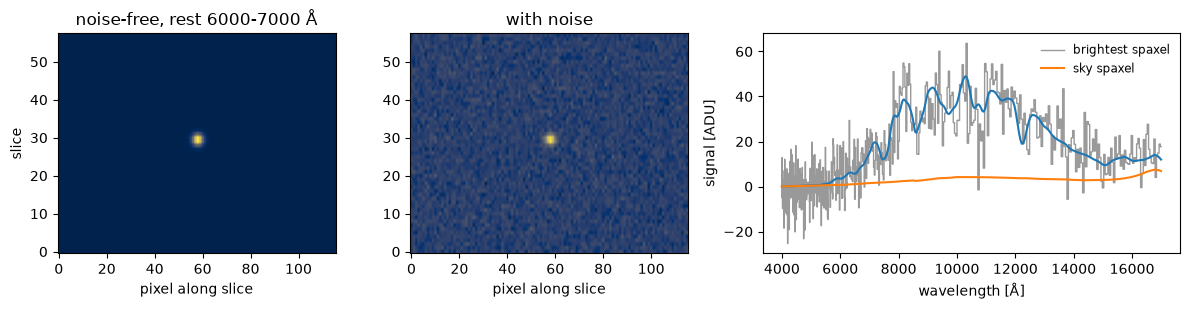

In [5]:
z = snia.get_properties("redshift")
in_band = (lbda > 6000 * (1 + z)) & (lbda < 7000 * (1 + z))   # rest-frame 6000-7000 Å
iy, ix = np.unravel_index(np.argmax(cube.sum(axis=0)), cube.shape[1:])

fig, (ax_img, ax_noisy, ax_spec) = plt.subplots(1, 3, figsize=(12, 3.2),
                                                gridspec_kw={"width_ratios": [1, 1, 1.5]})
prop = dict(origin="lower", aspect="auto", cmap="cividis")
ax_img.imshow(cube[in_band].sum(axis=0), **prop)
ax_img.set(title="noise-free, rest 6000-7000 Å", xlabel="pixel along slice", ylabel="slice")
ax_noisy.imshow(cube_noisy[in_band].sum(axis=0), **prop)
ax_noisy.set(title="with noise", xlabel="pixel along slice")

ax_spec.plot(lbda, cube_noisy[:, iy, ix], color="0.6", lw=1, ds="steps-mid", label="brightest spaxel")
ax_spec.plot(lbda, cube[:, iy, ix], color="C0")
ax_spec.plot(lbda, cube[:, 5, 5], color="C1", label="sky spaxel")
ax_spec.set(xlabel="wavelength [Å]", ylabel="signal [ADU]")
ax_spec.legend(frameon=False, fontsize="small")
fig.tight_layout()

Like spectra, cubes accept `switch_off`, e.g. to keep only the target:

In [6]:
cube_sn, _ = snia.get_cube(which="current", switch_off=["background", "thermal"])
print(f"target fraction of the signal: {cube_sn.sum() / cube.sum():.1%}")

target fraction of the signal: 0.8%


***
## 2. Both fields at once

`get_cube()` (default `which="both"`) simulates the narrow **and** the wide field. The target
position, defined in the current field, is converted into the frame of the other field, and the
current configuration is restored afterwards. `which="narrow"` or `"wide"` returns a single
field.

In [7]:
(cube_narrow, var_narrow), (cube_wide, var_wide) = snia.get_cube(which="both")
print(cube_narrow.shape, cube_wide.shape, snia.get_spectrograph_field()[0])

(525, 58, 116) (525, 58, 116) narrow


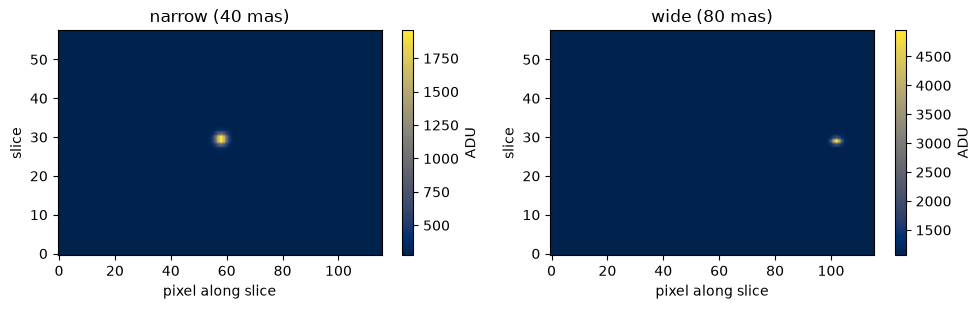

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (name, cube_) in zip(axes, {"narrow (40 mas)": cube_narrow, "wide (80 mas)": cube_wide}.items()):
    im = ax.imshow(cube_[in_band].sum(axis=0), origin="lower", aspect="auto", cmap="cividis")
    ax.set(title=name, xlabel="pixel along slice", ylabel="slice")
    fig.colorbar(im, ax=ax, label="ADU")
fig.tight_layout()

You can move the target (`position`, in spaxels, `(across slices, along slice)`) and switch the
current field with `change_spectrograph()`:

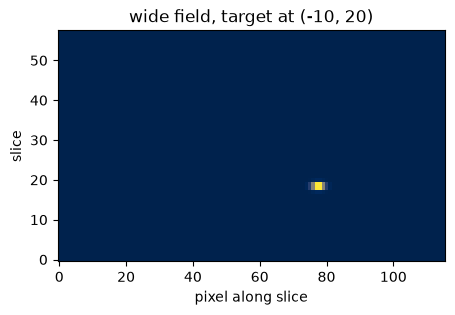

In [9]:
snia.change_spectrograph("wide")
snia.change_properties(position=(-10, 20))
cube_w, _ = snia.get_cube(which="current")

fig, ax = plt.subplots(figsize=(5, 3))
ax.imshow(cube_w[in_band].sum(axis=0), origin="lower", aspect="auto", cmap="cividis")
ax.set(title="wide field, target at (-10, 20)", xlabel="pixel along slice", ylabel="slice")

snia.change_spectrograph("narrow")      # back to the narrow field
snia.change_properties(position=(1, 0.5))

***
## 3. From cubes to the detector image: the mapper

Where each (slice, position along the slice, wavelength) lands on the detector is known from the
optical design (spot diagrams). `slicersim.mapper.SlicerMapper` interpolates it. The default
Lazuli spot data ships with `slicersim`.

In [10]:
import pandas
from slicersim.iotools import expand_path
from slicersim.mapper import SlicerMapper

spotdata = pandas.read_csv(expand_path("mapping_spotdata.csv"), sep=" ")
mapper = SlicerMapper.from_data(spotdata)
spotdata.head()  # slice, position along the slice [-1, 1], wavelength [µm] -> x, y [mm]

,slice,fieldpos,lbda,x,y,rmsx_um,rmsy_um
0,1.0,-1.0,0.35,17.783724,19.447246,2.190370,1.629596
1,1.0,-1.0,0.40,17.669517,17.666763,1.521143,1.698664
2,1.0,-1.0,0.50,17.547354,15.671237,1.019332,2.363389
3,1.0,-1.0,0.70,17.444972,13.912727,1.558027,3.231352
4,1.0,-1.0,1.00,17.378211,12.716326,2.302403,3.894424


In [11]:
# where does 1 µm fall, at the centre of the first narrow and first wide slices?
mapper.slice_pos_wave_to_xy(sliceid=[1, 59], fieldpos=0, lbda=10_000)  # [pixels]

array([[3731.6811, 3645.2759],
       [3317.1627, 1216.63  ]])

[(0.0, 4096.0),
 (0.0, 4096.0),
 Text(0.5, 1.0, 'slice footprints (colour: wavelength)')]

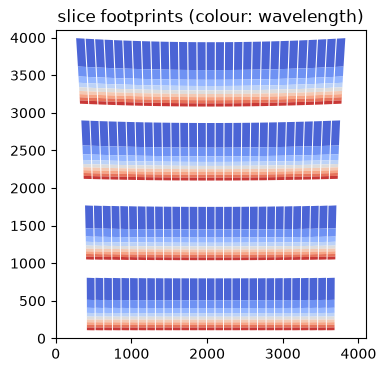

In [12]:
fig, ax = plt.subplots(figsize=(4, 4))
mapper.show_slices(np.arange(1, 117), ax=ax)
ax.set(xlim=(0, 4096), ylim=(0, 4096), title="slice footprints (colour: wavelength)")

Each slice is a vertical strip: the position along the slice runs along x, the wavelength along
y (blue at the top). Four rows of 29 slices fill the detector.

`mapper.project_lazulicube(cube, "narrow" | "wide", lbda)` projects the cube of one field.
Let us project the target alone to find where its spectrum lands:

In [13]:
image_sn = mapper.project_lazulicube(cube_sn, "narrow", lbda)

ys, xs = np.nonzero(image_sn > 0.01 * np.nanmax(image_sn))   # footprint of the SN trace
zoom = dict(xlim=(xs.min() - 50, xs.max() + 50), ylim=(ys.min() - 50, ys.max() + 50))
print(f"SN trace: x in [{xs.min()}, {xs.max()}], y in [{ys.min()}, {ys.max()}]")

SN trace: x in [349, 740], y in [2117, 3575]


`to_image()` generates both cubes (as `get_cube(which="both")`) and projects them onto the
detector: narrow field on slices 1–58, wide field on 59–116. *This takes ~30 s.*

In [14]:
%%time
image = snia.to_image(mapper)

CPU times: user 23.8 s, sys: 1.36 s, total: 25.1 s
Wall time: 25.1 s


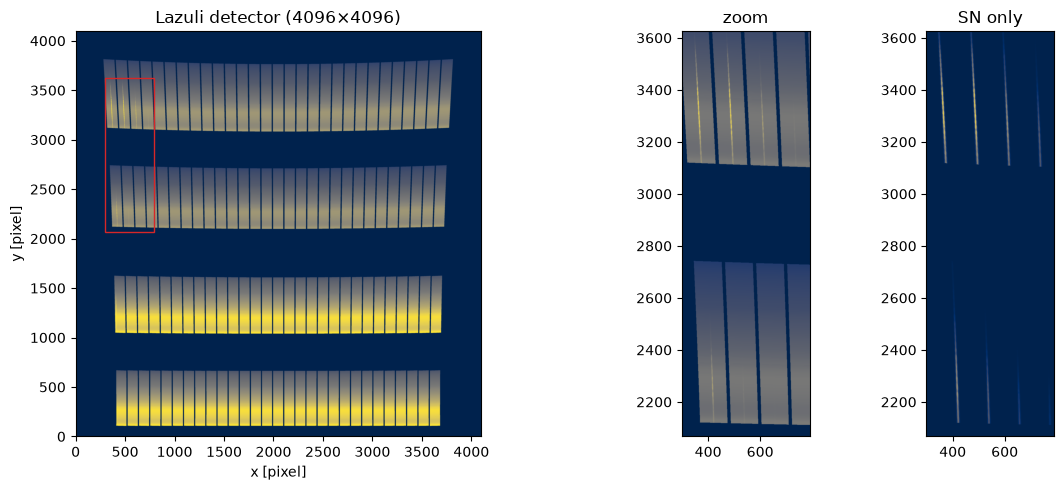

In [15]:
from matplotlib.colors import PowerNorm

fig, (ax, ax_zoom, ax_sn) = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={"width_ratios": [3, 1, 1]})
ax.imshow(image, origin="lower", norm=PowerNorm(0.3, vmin=0, vmax=np.nanpercentile(image, 99.9)), cmap="cividis")
ax.add_patch(plt.Rectangle((zoom["xlim"][0], zoom["ylim"][0]), np.diff(zoom["xlim"])[0], np.diff(zoom["ylim"])[0],
                           fill=False, color="C3"))
ax.set(title="Lazuli detector (4096×4096)", xlabel="x [pixel]", ylabel="y [pixel]")

cutout = image[zoom["ylim"][0]:zoom["ylim"][1], zoom["xlim"][0]:zoom["xlim"][1]]
ax_zoom.imshow(image, origin="lower", norm=PowerNorm(0.3, vmin=0, vmax=np.nanmax(cutout)), cmap="cividis")
ax_zoom.set(title="zoom", **zoom)
ax_sn.imshow(image_sn, origin="lower", norm=PowerNorm(0.3, vmin=0), cmap="cividis")
ax_sn.set(title="SN only", **zoom)
fig.tight_layout()

- The zodiacal and thermal backgrounds fill all the slices and increase towards the red (bottom
  of each slice); the SN traces sit on top of them.
- The SN light (PSF) spreads over a few adjacent slices. Adjacent on the sky does not mean
  adjacent on the detector: slices 1–29 fill the top row (right to left), so slices 30–31
  continue on the next row.

***
## Recap

- `get_cube(which="current" | "narrow" | "wide" | "both")` → `(cube, varcube)` in ADU, shape
  `(n_wavelength, n_slices, n_pixels_along_slice)`; accepts `switch_off`.
- `get_spectrograph_field()`, `change_spectrograph("narrow" | "wide")`; `position` moves the target.
- `SlicerMapper` maps the slicer onto the detector; `target.to_image(mapper)` gives the full
  detector image, `mapper.project_lazulicube()` projects a single field.

**Now, practice:** [exercises](exercises/)